<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB47 · Dinámica inversa y control con modelo

**Parte 6 · Simulación de bípedos a fondo — Bloque A: MuJoCo por dentro — Lección 3**

> Hay dos grandes familias de controladores. Los **sin modelo** no saben nada de la física del robot: el PD del NB40 empuja hacia el objetivo "a ciegas", y una política de RL aprende a base de probar. Los **con modelo** usan la física: saben cuánto pesa cada pieza y cómo se acoplan (la M del NB45), y calculan **de antemano** el par necesario.

En la industria se usan las dos. Boston Dynamics hizo andar y saltar a Atlas durante años con control basado en modelo (control predictivo y dinámica de todo el cuerpo); hoy casi todos los humanoides nuevos andan con políticas de RL, pero con un control de bajo nivel y muchas herramientas basadas en modelo alrededor. Un ingeniero de locomoción tiene que entender las dos, y saber **cuándo** conviene cada una. Preguntas típicas de entrevista:

- "¿Qué es la dinámica inversa? ¿Para qué sirve?"
- "¿Qué diferencia hay entre un PD con compensación de gravedad y el control por par calculado?"
- "¿Qué pasa si el modelo del robot no es exacto?"
- "¿Qué es el control en el espacio de la tarea (u operacional)?"

Hoy construiremos los cuatro controladores clásicos y los **mediremos** unos contra otros, en un banco de pruebas: una pierna de Zancudo colgada de un soporte.

En el hilo de Python, una pregunta de diseño: ¿cómo se organiza una **familia** de cosas intercambiables (aquí, controladores) para que el resto del código funcione con cualquiera de ellas? Las piezas ya las conoces del puente (**clases abstractas** y **protocolos** del P5, **composición** y `__call__` del P3, *callbacks* del P2); hoy las juntamos en un diseño completo, el **patrón estrategia**, que en el P2 solo asomó en su forma más simple.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 1 · La dinámica inversa

### De la aceleración a las fuerzas

En el NB45 vimos la ecuación del movimiento y sus dos direcciones:

```
   M(q) · q̈  +  c(q, q̇)  =  τ  +  (fuerzas pasivas, de contacto...)
```

- **Directa** (`mj_forward`): conozco τ, calculo q̈. Es **simular**.
- **Inversa** (`mj_inverse`): conozco q̈ (la aceleración que **quiero**), calculo τ. Es **controlar**: "para que la rodilla acelere así, ¿qué par le pido al motor?".

La inversa es, en principio, **más fácil**: no hay que resolver ningún sistema de ecuaciones, solo multiplicar M por q̈ y sumar c. (Con contactos se complica, porque hay que deducir también las fuerzas del suelo; lo veremos en el NB48.)

### Comprobación: ida y vuelta

La mejor forma de entender `mj_inverse` es hacer **ida y vuelta**. Tomamos Zancudo en el aire (sin contactos, para que sea limpio), le aplicamos unos pares cualesquiera, calculamos la aceleración que producen (directa), y después le preguntamos a la inversa qué fuerzas producirían **esa** aceleración. Deberían salir los pares de partida.

Para que la prueba sea clara, aplicamos los pares "a mano" con `qfrc_applied` (fuerzas aplicadas directamente a las articulaciones, NB45), y **apagamos los motores** de Zancudo (son motores de posición, NB40: con `ctrl = 0` empujarían con fuerza hacia la postura cero, y esas fuerzas se mezclarían en la cuenta):


In [2]:
zancudo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
zancudo.opt.disableflags |= mujoco.mjtDisableBit.mjDSBL_ACTUATION      # motores apagados (NB45, banderas de bits)
ida = mujoco.MjData(zancudo)
ida.qpos[1] = 0.5                                   # 50 cm más alto: en el aire
ida.qpos[3:9] = [0.3, -0.5, 0.1, -0.2, -0.9, 0.2]   # una postura cualquiera
ida.qvel[:] = np.linspace(-1, 1, zancudo.nv)        # y unas velocidades cualesquiera
pares = np.array([0, 0, 0, 5.0, -3.0, 1.0, 2.0, 4.0, -1.0])
ida.qfrc_applied[:] = pares
mujoco.mj_forward(zancudo, ida)                     # DIRECTA: pares → aceleración
print("aceleraciones:", ida.qacc)

vuelta = mujoco.MjData(zancudo)
vuelta.qpos[:] = ida.qpos
vuelta.qvel[:] = ida.qvel
vuelta.qacc[:] = ida.qacc                           # la aceleración que "queremos"
mujoco.mj_inverse(zancudo, vuelta)                  # INVERSA: aceleración → fuerzas
print("fuerzas necesarias:", vuelta.qfrc_inverse)
print("pares de partida:  ", pares)

aceleraciones: [  -4.4412  -10.3321   18.725    56.6558  -75.3704   55.8271   23.3142   16.5292 -137.9186]
fuerzas necesarias: [-0.  0.  0.  5. -3.  1.  2.  4. -1.]
pares de partida:   [ 0.  0.  0.  5. -3.  1.  2.  4. -1.]


¡Salen los mismos pares! `mj_inverse` lee `qpos`, `qvel` y **`qacc`** (que esta vez rellenamos **nosotros**) y escribe en **`qfrc_inverse`** las fuerzas que hacen falta. Hemos usado dos `MjData` distintos (`ida` y `vuelta`) para que no se mezclen: es lo limpio, NB45.

Las tres primeras casillas (la raíz) salen a cero: el robot está en el aire, nadie empuja su cuerpo, y la aceleración de la raíz es la que resulta de la gravedad y de mover las piernas. Si pidiéramos otra aceleración para la raíz, `qfrc_inverse` nos diría qué fuerza haría falta en ella... una fuerza que **ningún motor** puede hacer (Zancudo no tiene un motor que lo empuje en el aire). Es la idea de **subactuación** del NB03: la raíz de un robot con patas **no tiene motor**, y solo se mueve a través de los contactos con el suelo. Esto es lo que hace tan difícil el control de bípedos, y volveremos a ello en el NB52.

`qfrc_inverse` es exactamente "lo que hay que **añadir**" a las fuerzas que MuJoCo ya conoce (gravedad, amortiguadores, contactos): es decir, la suma de lo que hacen **los motores**, `qfrc_applied` y las fuerzas externas. Por eso apagamos los motores: con ellos encendidos, `qfrc_inverse` habría incluido también su empuje hacia la postura cero, y no habríamos recuperado solo nuestros pares. (Compruébalo: borra la línea del `disableflags` y vuelve a ejecutar.)


## 2 · El banco de pruebas: una pierna colgada

Para estudiar controladores sin las complicaciones del equilibrio, usaremos **una pierna de Zancudo colgada** de un soporte fijo en el aire, como en un banco de laboratorio. Así podemos medir lo bien que sigue una trayectoria sin que se caiga nada.

Dos cambios respecto a Zancudo:

- **Motores de par** (`<motor>`) en vez de motores de posición (`<position>`, NB40). Un `<motor>` aplica **exactamente** el par que le pides en `ctrl` (con `gear="1"`, el valor por defecto): así el controlador lo programamos **nosotros**, en Python. Limitado a ±150 N·m, como Zancudo.
- Un **marcador** verde: una esfera que no choca con nada y que moveremos a mano para señalar el objetivo. Es un cuerpo **`mocap`** ("de captura de movimiento"): un cuerpo que no obedece a la física, sino que se coloca directamente con `datos.mocap_pos`. Se usa para marcadores, para objetivos y para "arrastrar" robots con el ratón. Más en el NB50.


In [3]:
PIERNA = '''
<mujoco model="pierna_colgada">
  <compiler angle="radian"/>
  <option timestep="0.002"/>
  <default>
    <joint type="hinge" axis="0 -1 0" damping="1" armature="0.01"/>
    <motor ctrlrange="-150 150" ctrllimited="true"/>
  </default>
  <visual>
    <headlight ambient="0.5 0.5 0.5"/>
  </visual>
  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.5 0.6 0.7" rgb2="0.1 0.1 0.15" width="200" height="200"/>
  </asset>
  <worldbody>
    <light pos="0 -1 3" dir="0 0.3 -1"/>
    <camera name="lado" pos="0.15 -1.5 0.85" xyaxes="1 0 0  0 0 1"/>
    <body name="soporte" pos="0 0 1.2">
      <geom type="box" size="0.08 0.08 0.04" rgba="0.4 0.4 0.4 1" contype="0" conaffinity="0"/>
      <body name="muslo">
        <joint name="cadera" range="-1.57 1.57"/>
        <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.05" mass="3" rgba="0.85 0.55 0.25 1"/>
        <body name="pierna" pos="0 0 -0.4">
          <joint name="rodilla" range="-2.6 0"/>
          <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.04" mass="2" rgba="0.85 0.55 0.25 1"/>
          <body name="pie" pos="0 0 -0.4">
            <joint name="tobillo" range="-0.78 0.78"/>
            <geom type="capsule" fromto="-0.06 0 -0.03  0.14 0 -0.03" size="0.03" mass="0.8" rgba="0.85 0.55 0.25 1"/>
            <site name="tobillo" pos="0 0 0"/>
          </body>
        </body>
      </body>
    </body>
    <body name="objetivo" mocap="true" pos="0 0 0.6">
      <geom type="sphere" size="0.025" rgba="0.2 0.9 0.3 0.6" contype="0" conaffinity="0"/>
    </body>
  </worldbody>
  <actuator>
    <motor name="cadera" joint="cadera"/>
    <motor name="rodilla" joint="rodilla"/>
    <motor name="tobillo" joint="tobillo"/>
  </actuator>
</mujoco>
'''
modelo = mujoco.MjModel.from_xml_string(PIERNA)
datos = mujoco.MjData(modelo)
print("nq =", modelo.nq, "  nu =", modelo.nu, "  límites de las articulaciones (rad):")
print(modelo.jnt_range)

nq = 3   nu = 3   límites de las articulaciones (rad):
[[-1.57  1.57]
 [-2.6   0.  ]
 [-0.78  0.78]]


Tres articulaciones, tres motores, y los límites en **radianes**, como los escribimos.

### Trampa: grados o radianes

Fíjate en la línea `<compiler angle="radian"/>`. Parece un detalle, pero **sin ella todo falla en silencio**: por razones históricas, MuJoCo lee los ángulos del MJCF en **grados** si no se le dice otra cosa. Mira lo que pasaría:


In [4]:
sin_compiler = mujoco.MjModel.from_xml_string(PIERNA.replace('<compiler angle="radian"/>', ''))
print(sin_compiler.jnt_range)

[[-0.0274  0.0274]
 [-0.0454  0.    ]
 [-0.0136  0.0136]]


¡Los límites se han convertido en ±0,027 rad! MuJoCo leyó `-1.57 1.57` como ±1,57 **grados**, y los pasó a radianes. La cadera quedaría casi bloqueada, y el controlador "no funcionaría" sin ningún mensaje de error. (Me pasó a mí preparando este notebook: los cuatro controladores fallaban igual, y tardé un rato en ver por qué.)

**Regla:** pon **siempre** `<compiler angle="radian"/>` en tus MJCF. Y cuando un modelo se comporte de forma rara, mira `jnt_range`: es la comprobación más rápida. (Esto solo afecta a los ángulos **del fichero**: `qpos` y todo lo que MuJoCo calcula está siempre en radianes.)


## 3 · Python profesional: una familia de controladores (repaso del P2, P3 y P5)

### El problema de diseño

Vamos a escribir cuatro controladores, y queremos **una sola** función `simular` que funcione con cualquiera de ellos, para compararlos en igualdad de condiciones. Y mañana querremos añadir un quinto sin tocar `simular`. ¿Cómo se organiza eso?

La idea clave: `simular` **no necesita saber qué controlador es**. Solo necesita poder **pedirle los pares**: "dados el modelo y los datos de ahora, ¿qué pongo en `ctrl`?". Si todos los controladores responden a esa misma pregunta de la misma forma, son **intercambiables**. A esa "forma común de responder" se le llama una **interfaz**.

Este diseño tiene nombre: el **patrón estrategia** (*strategy pattern*; en el P2 lo viste en su versión mínima, con un diccionario de funciones). La "estrategia" (el controlador) se elige desde fuera y se le pasa al código que la usa (`simular`), que solo conoce la interfaz. Lo usas sin saberlo desde el NB34: `PPO("MlpPolicy", ...)` recibe la política como estrategia, y Gymnasium define una interfaz (`reset`, `step`) que todos los entornos cumplen (NB25).

### Clases abstractas (repaso del NB25 y del P5)

En Python, la forma más explícita de definir una interfaz es una **clase abstracta**, con el módulo `abc` (*abstract base classes*) de la biblioteca estándar. Ya la usaste en el NB25 para las políticas, y en el P5 la comparaste con `Protocol`:


In [5]:
from abc import ABC, abstractmethod

class Controlador(ABC):
    """Algo que, dado el estado del robot, decide los pares de los motores."""

    @abstractmethod
    def __call__(self, modelo: mujoco.MjModel, datos: mujoco.MjData) -> np.ndarray:
        """Devuelve el vector de controles (uno por motor)."""

Tres cosas que ya conoces, juntas:

- **`class Controlador(ABC)`**: hereda de `ABC`, lo que la convierte en clase abstracta.
- **`@abstractmethod`**: marca un método como **obligatorio**. La clase abstracta no lo implementa (solo tiene la docstring); cada clase hija **tiene que** implementarlo.
- **`__call__`** (P3): el método especial que hace que los objetos se puedan **llamar como funciones**: si `c` es un controlador, `c(modelo, datos)` ejecuta `c.__call__(modelo, datos)`. Es muy natural para cosas que "son" una función con memoria (como una política: `politica(observacion)`, NB43).

Recordemos qué gana uno con una clase abstracta: dos protecciones. La primera: **no se puede crear** un "controlador" genérico, que no sabría qué hacer:


In [6]:
Controlador()

TypeError: Can't instantiate abstract class Controlador without an implementation for abstract method '__call__'

`TypeError: Can't instantiate abstract class Controlador without an implementation for abstract method '__call__'`. La segunda, más útil: si escribes un controlador y **se te olvida** implementar el método obligatorio (o te equivocas en el nombre, que es lo más común), Python te avisa **al crearlo**, no más tarde, a mitad de una simulación:


In [7]:
class ControladorDespistado(Controlador):
    def __cal__(self, modelo, datos):          # ¡una "l" de menos!
        return np.zeros(modelo.nu)

ControladorDespistado()

TypeError: Can't instantiate abstract class ControladorDespistado without an implementation for abstract method '__call__'

El error salta en cuanto intentas crear el objeto, y dice exactamente qué falta. Sin la clase abstracta, el error aparecería al llamar al controlador, con un mensaje mucho menos claro ("object is not callable").

### La trayectoria de referencia

Los controladores necesitan saber **qué** queremos que haga la pierna en cada instante: la posición, la velocidad y la aceleración deseadas (q, q̇, q̈). Lo escribimos como **otra** pequeña familia: una postura fija, o un vaivén sinusoidal. Esta vez como dataclasses congeladas (NB45), con un método común `en(t)`:


In [8]:
from dataclasses import dataclass

@dataclass(frozen=True)
class PosturaFija:
    q: tuple[float, ...]

    def en(self, t: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        q = np.array(self.q)
        return q, np.zeros_like(q), np.zeros_like(q)


@dataclass(frozen=True)
class Vaiven:
    frecuencia: float                              # vueltas por segundo (Hz)
    centro: tuple[float, ...] = (0.0, -0.8, 0.0)
    amplitud: tuple[float, ...] = (0.5, 0.5, 0.0)

    def en(self, t: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        w = 2 * np.pi * self.frecuencia            # velocidad angular del vaivén (rad/s)
        c, a = np.array(self.centro), np.array(self.amplitud)
        q = c + a * np.sin(w * t)
        qd = a * w * np.cos(w * t)                 # derivada del seno: coseno (NB16)
        qdd = -a * w**2 * np.sin(w * t)            # y otra vez: menos seno
        return q, qd, qdd

print(Vaiven(0.5).en(0.5))

(array([ 0.5, -0.3,  0. ]), array([0., 0., 0.]), array([-4.9348, -4.9348, -0.    ]))


El vaivén mueve la cadera y la rodilla a la vez (±0,5 rad alrededor de 0 y de −0,8), con el tobillo quieto. Su velocidad y su aceleración son las **derivadas** del seno (NB16): derivar sen(wt) da w·cos(wt), y derivar otra vez, −w²·sen(wt). Fíjate en el **w²**: si duplicas la frecuencia, la aceleración se multiplica por **cuatro**. Eso importará mucho en la sección 7.

`np.zeros_like(q)` crea un array de ceros con la misma forma y tipo que `q`. Y `tuple[float, ...]` es la anotación de "una tupla de decimales, de cualquier longitud" (los `...` son literales: forman parte de la sintaxis). Usamos tuplas, no arrays, como valores por defecto: son inmutables (NB21), y una dataclass **no permite** arrays ni listas como valores por defecto, precisamente por la trampa de los mutables (NB23, NB46).

### Protocolos: interfaces sin herencia (repaso del P5)

`PosturaFija` y `Vaiven` no heredan de ninguna clase común, y sin embargo son intercambiables: las dos tienen un método `en(t)`. Es el **tipado de pato** (*duck typing*) que viste en el P5: "si anda como un pato y hace cua como un pato, es un pato"; lo que importa es lo que un objeto **sabe hacer**, no de qué clase es.

Y, como en el P5, para **documentar** (y que mypy pueda comprobar) esas interfaces "de pato" usamos un **protocolo**, del módulo `typing`:


In [9]:
from typing import Protocol

class Trayectoria(Protocol):
    def en(self, t: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]: ...

Un `Protocol` dice "una `Trayectoria` es **cualquier cosa** que tenga un método `en(t)` que devuelva tres arrays". `PosturaFija` y `Vaiven` **cumplen** el protocolo sin haberlo mencionado nunca: no heredan de él. (Los `...` del cuerpo son literales: el protocolo solo describe, no implementa.)

Recordatorio de la tabla del P5: ¿cuándo usar cada cosa?

| | Clase abstracta (ABC) | Protocolo |
|---|---|---|
| Cómo se cumple | heredando explícitamente | teniendo los métodos (sin heredar) |
| Comprobación | al **crear** el objeto (en ejecución) | solo con mypy/pyright (antes de ejecutar) |
| Puede traer código común | sí (métodos normales que heredan las hijas) | no, solo describe |
| Ideal para | tus propias familias de clases | aceptar cosas de **otros** (bibliotecas, funciones) que no puedes hacer heredar de nada |

En la práctica, los dos conviven. Aquí usamos una ABC para los controladores (son nuestros, y queremos la protección al crearlos) y un protocolo para las trayectorias (cualquier cosa con `en` vale; incluso podríamos meter ahí una trayectoria grabada de una persona, NB57).


### La función simular

Ahora, la función que usa a los controladores sin saber cuáles son. Y aquí cumplimos una promesa del NB45: usar **`mj_step1` y `mj_step2`** para que el controlador vea las cantidades **del instante actual** (la matriz de masas, las fuerzas de sesgo...). `mj_step1` calcula las etapas de posición y velocidad; el controlador decide; `mj_step2` hace el resto.

Devolverá un **registro** de la simulación, otra dataclass:


In [10]:
@dataclass
class Registro:
    tiempo: np.ndarray
    qpos: np.ndarray
    ctrl: np.ndarray
    sitio: np.ndarray                      # posición del site del tobillo en cada instante


def simular(modelo: mujoco.MjModel, controlador: Controlador, segundos: float,
            q_inicial, qd_inicial=None, al_paso=None) -> Registro:
    datos = mujoco.MjData(modelo)
    datos.qpos[:] = q_inicial
    datos.qvel[:] = 0 if qd_inicial is None else qd_inicial
    mujoco.mj_forward(modelo, datos)
    tiempos, posturas, controles, sitios = [], [], [], []
    while datos.time < segundos:
        mujoco.mj_step1(modelo, datos)                 # posición y velocidad del instante actual
        datos.ctrl[:] = controlador(modelo, datos)     # la ESTRATEGIA decide
        mujoco.mj_step2(modelo, datos)                 # fuerzas, aceleración, integración
        tiempos.append(datos.time)
        posturas.append(datos.qpos.copy())             # ¡copias! (NB45)
        controles.append(datos.ctrl.copy())
        sitios.append(datos.site_xpos[0].copy())
        if al_paso is not None:
            al_paso(datos)
    return Registro(np.array(tiempos), np.array(posturas), np.array(controles), np.array(sitios))

Detalles:

- **`controlador: Controlador`**: la anotación dice "cualquier cosa que cumpla la interfaz de `Controlador`". `simular` solo hace `controlador(modelo, datos)`. Nada más. No sabe ni le importa si es un PD o un par calculado.
- **`al_paso=None`**: un argumento opcional que es **una función** (NB23 y P2: las funciones son objetos y se pueden pasar). Si nos la dan, se llama en cada paso con los datos: nos servirá para mover el marcador verde o para hacer fotos. Es un ***callback*** (de "llamar de vuelta"), como los del P2. SB3 usa callbacks para lo mismo (NB55).
- **Al final, `np.array(lista_de_arrays)`** convierte la lista de 2.000 arrays de 3 números en **un** array de 2.000 × 3. Acumular en listas y convertir al final es mucho más rápido que ir pegando arrays de NumPy en cada paso.

Y una función para medir el error de seguimiento, en las dos articulaciones que se mueven (cadera y rodilla). Usamos la **raíz del error cuadrático medio** (*RMS*, NB18): la medida estándar.


In [11]:
def error_rms(registro: Registro, trayectoria: Trayectoria) -> float:
    deseadas = np.array([trayectoria.en(t)[0] for t in registro.tiempo])
    diferencia = registro.qpos[:, :2] - deseadas[:, :2]
    return float(np.sqrt(np.mean(diferencia**2)))

## 4 · Controlador 1: el PD de siempre

Empezamos por el controlador del NB40: par = Kp · (error de posición) + Kd · (error de velocidad). Ahora como una clase de la familia:


In [12]:
KP = np.array([100.0, 100.0, 20.0])           # rigidez: N·m por radián de error
KD = np.array([20.0, 20.0, 2.0])              # amortiguación: N·m por rad/s de error


class PD(Controlador):
    def __init__(self, trayectoria: Trayectoria, kp: np.ndarray = KP, kd: np.ndarray = KD):
        self.trayectoria = trayectoria
        self.kp, self.kd = kp, kd

    def __call__(self, modelo, datos):
        q, qd, _ = self.trayectoria.en(datos.time)
        return self.kp * (q - datos.qpos) + self.kd * (qd - datos.qvel)

    def __repr__(self):
        return f"PD(kp={self.kp}, kd={self.kd})"


quieta = PosturaFija((0.5, -0.3, 0.0))
registro = simular(modelo, PD(quieta), 3.0, q_inicial=quieta.q)
print("postura final:", registro.qpos[-1], "  deseada:", quieta.q)
print(f"error RMS: {error_rms(registro, quieta):.4f} rad")

postura final: [ 0.4201 -0.311  -0.0167]   deseada: (0.5, -0.3, 0.0)
error RMS: 0.0549 rad


La pierna debía quedarse en (0,5, −0,3, 0), y se ha quedado en (0,420, −0,311, −0,017): la cadera ha **caído** 0,08 rad (unos 4,6°) por debajo del objetivo. Es la **caída** del NB40: para que el PD haga par, **tiene que haber error**. La gravedad tira de la pierna con unos 8 N·m en la cadera, y el PD solo los iguala cuando el error es de 8 / 100 = 0,08 rad. Un PD puro sujetando un peso **siempre** se queda un poco por debajo.

Podríamos subir Kp para que la caída fuera menor... pero un Kp enorme hace al robot rígido y peligroso, amplifica el ruido de los sensores (NB41) y, con los retrasos de un robot real, acaba oscilando. Hay una forma mejor.


## 5 · Controlador 2: compensar la gravedad

### La idea

Si sabemos **cuánto par hace la gravedad** en cada articulación, podemos **sumarlo** al PD: el motor sostiene el peso por su cuenta, y el PD solo tiene que corregir los errores. Ese par de la gravedad lo calcula MuJoCo: es (parte de) las **fuerzas de sesgo** `qfrc_bias` del NB45. Recuerda que, con la pierna quieta, `qfrc_bias` es **solo** la gravedad; con la pierna moviéndose, incluye también los efectos de los giros (centrífugos y de Coriolis).

Así que el controlador "gravedad" es facilísimo: devolver `qfrc_bias`. Y gracias a `mj_step1`, está calculado **para el instante actual**:


In [13]:
class Gravedad(Controlador):
    def __call__(self, modelo, datos):
        return datos.qfrc_bias.copy()

    def __repr__(self):
        return "Gravedad()"

### Composición: sumar controladores

Ahora, ¿cómo hacemos "PD + gravedad"? Una opción sería escribir una clase `PDConGravedad` que herede de `PD` y sume `qfrc_bias`. Pero mañana querremos "par calculado + algo", "espacio de tarea + gravedad"... y acabaríamos con una clase por cada combinación.

Mucho mejor: un controlador que **suma** los de otros, sean cuales sean. En vez de **heredar** (ser un tipo de PD), **contiene** otros controladores. Esto se llama **composición**, y es uno de los consejos más repetidos del diseño de software: **"prefiere la composición a la herencia"**.


In [14]:
class Suma(Controlador):
    def __init__(self, *partes: Controlador):
        self.partes = partes

    def __call__(self, modelo, datos):
        return sum(parte(modelo, datos) for parte in self.partes)

    def __repr__(self):
        return " + ".join(repr(parte) for parte in self.partes)


pd_con_gravedad = Suma(PD(quieta), Gravedad())
print(pd_con_gravedad)
registro = simular(modelo, pd_con_gravedad, 3.0, q_inicial=quieta.q)
print("postura final:", registro.qpos[-1])
print(f"error RMS: {error_rms(registro, quieta):.6f} rad")

PD(kp=[100. 100.  20.], kd=[20. 20.  2.]) + Gravedad()


postura final: [ 0.5 -0.3  0. ]
error RMS: 0.000000 rad


**Error cero**: la pierna se queda exactamente donde debe. El término de gravedad sostiene el peso, y el PD, sin nada contra lo que luchar, no necesita error. Esto se usa en **todos** los brazos robóticos modernos: es la diferencia entre un brazo que "cede" un poco y uno que se queda clavado.

Y fíjate en el `print`: gracias a los `__repr__`, la composición se describe sola, `PD(...) + Gravedad()`. Dos detalles más:

- **`*partes`** en el `__init__` (NB23): acepta **cualquier número** de controladores, que llegan como una tupla. `Suma(a, b, c)` funciona igual que `Suma(a, b)`.
- **`sum(parte(modelo, datos) for parte in self.partes)`**: una **expresión generadora** (NB21; la viste a fondo en el P4) que va llamando a cada parte; `sum` suma los arrays que devuelven.


## 6 · Controlador 3: el par calculado

### Usar todo el modelo

Compensar la gravedad está muy bien con la pierna quieta. Pero si la pierna se **mueve deprisa**, aparece otra cosa que el PD tiene que vencer: la **inercia** (el término M·q̈). Para acelerar el muslo hacen falta pares, y el PD solo los da "a toro pasado", cuando ya hay error.

La idea del **par calculado** (*computed torque*) es usar la dinámica inversa **entera**: decidir qué **aceleración** queremos, y pedirle a `mj_inverse` el par que la produce. ¿Y qué aceleración queremos? La de la trayectoria, más una corrección que empuje hacia ella si nos hemos desviado:

```
   aceleración deseada  a  =  q̈_deseada  +  Kp · (q_deseada − q)  +  Kd · (q̇_deseada − q̇)
   par                   τ  =  dinámica_inversa(q, q̇, a)  =  M(q)·a + c(q, q̇) − (pasivas)
```

### Por qué es tan bueno

Si el modelo es **exacto**, la dinámica inversa consigue que la aceleración real sea **exactamente** `a`. Llamando e = q_deseada − q al error, eso significa:

```
   ë  +  Kd · ė  +  Kp · e  =  0
```

¡La ecuación de un **muelle con amortiguador** (NB39b, NB40), **igual para todas las articulaciones** y **sin** gravedad, sin inercias, sin acoplamientos! Toda la complicación de la física ha desaparecido: el controlador la ha **cancelado** con el modelo. Por eso este método se llama también **linealización por realimentación** (*feedback linearization*): convierte un sistema complicado (no lineal) en uno sencillo (lineal), que se sabe ajustar con fórmulas.

En particular, las ganancias tienen ahora un significado limpio, y ya lo conoces del NB39b: el error se comporta como un oscilador con **frecuencia natural** ω = √Kp y **amortiguamiento** ζ = Kd / (2√Kp) (las fórmulas del muelle, ω = √(k/m) y ζ = c / (2·√(k·m)), con k = Kp, c = Kd y una "masa" de 1, porque aquí controlamos directamente la aceleración). Con nuestras ganancias de cadera y rodilla (Kp = 100, Kd = 20): ω = 10 rad/s y ζ = 1, el **amortiguamiento crítico**: el error vuelve a cero lo más rápido posible **sin oscilar**. (Cuidado con las unidades: aquí Kp multiplica radianes para dar **aceleraciones**, rad/s², no pares. Usamos los mismos números que en el PD para comparar, pero no significan lo mismo.)

Para llamar a `mj_inverse` sin estropear los datos de la simulación, el controlador lleva sus **propios datos** de trabajo (NB46: funciones "puras"). Y le pasamos, como opción, el **modelo que el controlador cree** que tiene el robot: lo usaremos en la sección 8.


In [15]:
class ParCalculado(Controlador):
    def __init__(self, trayectoria: Trayectoria, modelo_interno: mujoco.MjModel,
                 kp: np.ndarray = KP, kd: np.ndarray = KD):
        self.trayectoria = trayectoria
        self.modelo_interno = modelo_interno           # el modelo que el controlador CREE que es el robot
        self.trabajo = mujoco.MjData(modelo_interno)   # sus propios datos
        self.kp, self.kd = kp, kd

    def __call__(self, modelo, datos):
        q, qd, qdd = self.trayectoria.en(datos.time)
        a = qdd + self.kp * (q - datos.qpos) + self.kd * (qd - datos.qvel)
        self.trabajo.qpos[:] = datos.qpos
        self.trabajo.qvel[:] = datos.qvel
        self.trabajo.qacc[:] = a
        mujoco.mj_inverse(self.modelo_interno, self.trabajo)
        return self.trabajo.qfrc_inverse.copy()

    def __repr__(self):
        return "ParCalculado()"

registro = simular(modelo, ParCalculado(quieta, modelo), 3.0, q_inicial=quieta.q)
print(f"postura fija, error RMS: {error_rms(registro, quieta):.6f} rad")

postura fija, error RMS: 0.000000 rad


Con la postura fija, el par calculado también da error prácticamente nulo, como PD + gravedad: con la pierna quieta, M·q̈ es cero y los dos hacen lo mismo. La diferencia aparecerá cuando la pierna se mueva.


## 7 · La carrera: más y más deprisa

Ahora sí, la comparación. Hacemos que la pierna siga el vaivén a distintas frecuencias, desde la postura fija (0 Hz) hasta una vuelta por segundo (1 Hz, que con ±0,5 rad es bastante brusco: aceleraciones de casi 20 rad/s²), y medimos el error RMS de cada controlador.

Cada simulación empieza **sobre** la trayectoria (posición y velocidad deseadas en t = 0), para medir solo cómo la **sigue**:


In [16]:
frecuencias = [0.0, 0.1, 0.25, 0.5, 1.0]

def fabricar(nombre: str, trayectoria: Trayectoria) -> Controlador:
    if nombre == "PD":
        return PD(trayectoria)
    if nombre == "PD + gravedad":
        return Suma(PD(trayectoria), Gravedad())
    if nombre == "par calculado":
        return ParCalculado(trayectoria, modelo)
    raise ValueError(f"controlador desconocido: {nombre}")

resultados = {nombre: [] for nombre in ["PD", "PD + gravedad", "par calculado"]}
for f in frecuencias:
    trayectoria = PosturaFija((0.5, -0.3, 0.0)) if f == 0 else Vaiven(f)
    q0, qd0, _ = trayectoria.en(0.0)
    for nombre in resultados:
        registro = simular(modelo, fabricar(nombre, trayectoria), 4.0, q0, qd0)
        resultados[nombre].append(error_rms(registro, trayectoria))

print("frecuencia:      " + "".join(f"{f:>9.2f}" for f in frecuencias))
for nombre, errores in resultados.items():
    print(f"{nombre:<16} " + "".join(f"{e:9.4f}" for e in errores))

frecuencia:           0.00     0.10     0.25     0.50     1.00
PD                  0.0555   0.0395   0.0594   0.0409   0.0960
PD + gravedad       0.0000   0.0027   0.0125   0.0442   0.1368
par calculado       0.0000   0.0000   0.0001   0.0005   0.0017


(`fabricar` es una pequeña **fábrica**, *factory*: una función que crea objetos a partir de un nombre. En el P2 fabricabas **funciones** con cierres; aquí fabricamos **objetos**. Es la pareja natural del patrón estrategia: el resto del código elige la estrategia por su nombre, por ejemplo desde un fichero de configuración, NB53.)

Dibujado (con el eje vertical **logarítmico**, porque los errores van de 0,0000 a 0,2):


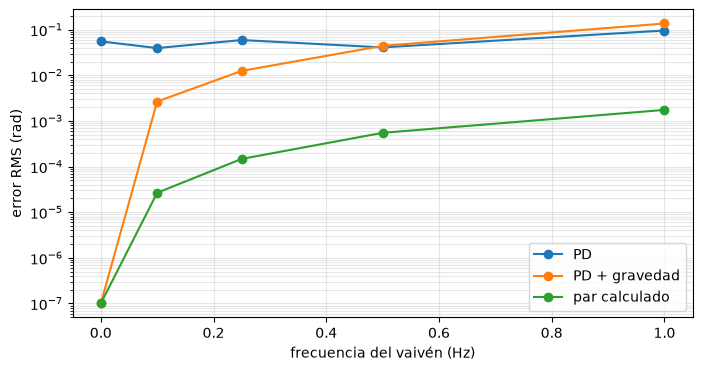

In [17]:
plt.figure(figsize=(8, 4))
for nombre, errores in resultados.items():
    plt.semilogy(frecuencias, np.maximum(errores, 1e-7), "o-", label=nombre)
plt.xlabel("frecuencia del vaivén (Hz)")
plt.ylabel("error RMS (rad)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

La tabla cuenta toda la historia de esta lección:

- **Quieta (0 Hz):** el PD se queda con su caída (0,056 rad RMS); los otros dos, error **cero**.
- **Despacio (0,1 y 0,25 Hz):** PD + gravedad ya va bastante bien (0,003 y 0,013); el par calculado, casi perfecto.
- **Deprisa (0,5 y 1 Hz):** PD + gravedad se viene abajo, ¡y a 1 Hz es **peor** que el PD solo (0,137 frente a 0,096)! Con la pierna moviéndose deprisa, lo que domina ya no es la gravedad, sino la **inercia** (acelerar y frenar el muslo), y PD + gravedad no la prevé. (¿Por qué peor que el PD? Porque, por casualidad, la caída del PD por la gravedad iba en el sentido de "ayudar" un poco con la inercia en parte del ciclo; al quitarla, el retraso por la inercia queda al descubierto. No hay que darle más vueltas: ninguno de los dos está preparado para movimientos rápidos.)
- **El par calculado** sigue la trayectoria con errores de **milésimas** a cualquier velocidad: 0,0017 rad a 1 Hz, **56 veces menos** que el PD. Prevé la inercia, la gravedad y los acoplamientos, porque usa el modelo entero.

Es, en resumen, la jerarquía clásica: **PD < PD + gravedad < par calculado**, cuanto más dinámico es el movimiento.


## 8 · El talón de Aquiles: un modelo equivocado

El par calculado parece magia. Pero tiene una condición escondida: **el modelo tiene que ser correcto**. Cancela la física **que cree** que tiene el robot; si se equivoca, cancela la física **equivocada**.

En un robot real, el modelo **nunca** es exacto: las masas del fabricante son aproximadas, los cables y los tornillos pesan, los motores tienen rozamientos que el modelo no incluye... Simulemos esa situación: el controlador cree que las piezas pesan un **30 % más** de lo que pesan (y con inercias un 30 % mayores):


In [18]:
modelo_equivocado = mujoco.MjModel.from_xml_string(PIERNA)
modelo_equivocado.body_mass[:] *= 1.3
modelo_equivocado.body_inertia[:] *= 1.3

errores_equivocado = []
for f in frecuencias:
    trayectoria = PosturaFija((0.5, -0.3, 0.0)) if f == 0 else Vaiven(f)
    q0, qd0, _ = trayectoria.en(0.0)
    registro = simular(modelo, ParCalculado(trayectoria, modelo_equivocado), 4.0, q0, qd0)
    errores_equivocado.append(error_rms(registro, trayectoria))

print("frecuencia:                " + "".join(f"{f:>9.2f}" for f in frecuencias))
print("par calculado (modelo ok)  " + "".join(f"{e:9.4f}" for e in resultados["par calculado"]))
print("par calculado (+30 % masa) " + "".join(f"{e:9.4f}" for e in errores_equivocado))
print("PD                         " + "".join(f"{e:9.4f}" for e in resultados["PD"]))

frecuencia:                     0.00     0.10     0.25     0.50     1.00
par calculado (modelo ok)     0.0000   0.0000   0.0001   0.0005   0.0017
par calculado (+30 % masa)    0.0627   0.0637   0.0531   0.0593   0.0851
PD                            0.0555   0.0395   0.0594   0.0409   0.0960


(Fíjate en la **separación** entre el robot "de verdad" (`modelo`, que es el que se simula) y lo que **cree** el controlador (`modelo_equivocado`). Es la situación de cualquier robot real, y por eso `ParCalculado` recibe su modelo aparte.)

**El par calculado ha perdido casi toda su ventaja.** Con el modelo equivocado, sus errores (0,05 a 0,09 rad) son del mismo orden que los del PD, y quieto es incluso algo **peor** (0,063 frente a 0,056). ¿Por qué? El controlador cree que la gravedad tira un 30 % más fuerte de lo que tira: **sobrecompensa**, y empuja la pierna hacia arriba más de la cuenta. Y al acelerar, multiplica por una M un 30 % mayor: cada corrección es un 30 % más brusca de lo debido.

Lecciones para la entrevista:

1. **El control con modelo es tan bueno como su modelo.** Por eso, antes de usarlo en un robot real, hay que **identificar** el modelo con medidas (NB61).
2. Se puede hacer más **robusto**: añadiendo un término **integral** (ejercicio E2), estimando las masas sobre la marcha (**control adaptativo**), o diseñando para el peor caso (**control robusto**).
3. Es una de las razones del éxito del **RL con aleatorización de dominio** (NB55): en vez de confiar en un modelo exacto, se entrena la política con miles de modelos **distintos** (masas, rozamientos...), y aprende a funcionar con todos.


## 9 · Controlador 4: el espacio de la tarea

### Mover el pie, no las articulaciones

Los tres controladores anteriores siguen una trayectoria **de las articulaciones** (ángulos). Pero muchas veces lo que nos importa es **dónde va el pie**: "llévalo a ese punto, por este camino". La solución del NB46 era hacer cinemática inversa en cada punto y luego seguir los ángulos. Hay otra forma, más directa y muy elegante: controlar **en el espacio de la tarea** (*task space* u *operational space*).

La idea usa el jacobiano **dos veces** (NB46):

1. Un "PD en el espacio": calculamos qué **fuerza** querríamos aplicar al tobillo para llevarlo al objetivo, como un muelle con amortiguador que tira de él: **F = Kx · (x_deseada − x) + Dx · (v_deseada − v)**, con v = J·q̇.
2. Convertimos esa fuerza en **pares** de los motores con **τ = Jᵀ·F** (el trabajo virtual del NB46).
3. Y le sumamos la compensación de la gravedad.

¡Sin cinemática inversa! Es como si un muelle invisible tirara del tobillo hacia el objetivo, y los motores lo "imitaran".

### También la orientación del pie

En el NB46 el pie se inclinaba al dibujar el círculo. Aquí lo podemos arreglar en el mismo controlador: además de la posición del tobillo, controlamos el **ángulo** del pie con el jacobiano de **rotación** (fila y, el eje de giro de las bisagras): un "PD de ángulo" que da un **par** sobre el pie, convertido a pares de los motores con la misma idea, Jᵀ_rot · par.

Para medir el ángulo del pie, lo sacamos de su matriz de rotación (NB46). El pie solo puede girar alrededor del eje y (Zancudo es plano), y para un giro de θ alrededor de y la matriz es la de `giro_y` del NB46, en la que R[0, 2] = sen θ y R[2, 2] = cos θ. Así que θ = `arctan2(R[0, 2], R[2, 2])`, con el **mismo** sentido de giro (alrededor de +y) que mide la fila y del jacobiano de rotación. (Cuidado con este tipo de cuentas: al preparar este notebook me equivoqué de casilla, saqué el ángulo con el signo cambiado, y el controlador de orientación empujaba el pie **al revés**: ¡75° de inclinación! Cuando un controlador empeora las cosas en vez de mejorarlas, sospecha primero de un signo.)


In [19]:
PIE = modelo.body("pie").id
TOBILLO = modelo.site("tobillo").id

def inclinacion_pie(datos) -> float:
    R = datos.xmat[PIE].reshape(3, 3)
    return float(np.arctan2(R[0, 2], R[2, 2]))        # el ángulo girado alrededor de +y


@dataclass(frozen=True)
class Circulo:
    centro: tuple[float, float, float] = (0.1, 0.0, 0.6)
    radio: float = 0.1
    frecuencia: float = 0.5

    def en(self, t: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        w = 2 * np.pi * self.frecuencia
        c = np.array(self.centro)
        x = c + self.radio * np.array([np.cos(w * t), 0.0, np.sin(w * t)])
        v = self.radio * w * np.array([-np.sin(w * t), 0.0, np.cos(w * t)])
        a = -self.radio * w**2 * np.array([np.cos(w * t), 0.0, np.sin(w * t)])
        return x, v, a


class EspacioTarea(Controlador):
    def __init__(self, trayectoria: Trayectoria, kx=800.0, dx=60.0, k_giro=40.0, d_giro=4.0,
                 con_orientacion: bool = True):
        self.trayectoria = trayectoria
        self.kx, self.dx, self.k_giro, self.d_giro = kx, dx, k_giro, d_giro
        self.con_orientacion = con_orientacion
        self.jac_pos = np.zeros((3, 3))
        self.jac_giro = np.zeros((3, 3))

    def __call__(self, modelo, datos):
        x_deseada, v_deseada, _ = self.trayectoria.en(datos.time)
        mujoco.mj_jacSite(modelo, datos, self.jac_pos, self.jac_giro, TOBILLO)
        x = datos.site_xpos[TOBILLO]
        v = self.jac_pos @ datos.qvel
        fuerza = self.kx * (x_deseada - x) + self.dx * (v_deseada - v)
        pares = self.jac_pos.T @ fuerza                                      # τ = Jᵀ·F
        if self.con_orientacion:
            giro = self.jac_giro[1] @ datos.qvel                             # velocidad de giro del pie (eje y)
            par_pie = self.k_giro * (0.0 - inclinacion_pie(datos)) + self.d_giro * (0.0 - giro)
            pares += self.jac_giro[1] * par_pie                              # τ += Jᵀ_giro · par
        return pares + datos.qfrc_bias                                       # + compensación de gravedad

    def __repr__(self):
        return f"EspacioTarea(orientación={'sí' if self.con_orientacion else 'no'})"

Fíjate en dos cosas del código:

- **`mj_jacSite` sin `mj_forward`**: dentro de `simular`, el controlador se llama justo después de `mj_step1`, que ya ha calculado todo lo necesario (incluido `mj_comPos`, la trampa del NB46).
- **El controlador guarda sus arrays de trabajo** (`self.jac_pos`, `self.jac_giro`) en vez de crearlos en cada llamada. Con 500 llamadas por segundo, evitar crear memoria nueva cada vez es un hábito de código de control profesional (en C++ es casi obligatorio).

Y el `Circulo` cumple el protocolo `Trayectoria` (tiene `en`), aunque devuelve posiciones del pie en vez de ángulos: el protocolo solo exige la **forma**, el significado lo pone cada controlador.

Probémoslo con y sin el control de la orientación, empezando con la pierna doblada (fuera del círculo) y midiendo a partir del segundo 1, cuando ya ha llegado:


In [20]:
circulo = Circulo()
q_partida = np.array([0.9, -1.4, 0.5])

for orientacion in (True, False):
    inclinaciones = []
    registro = simular(modelo, EspacioTarea(circulo, con_orientacion=orientacion), 4.0, q_partida,
                       al_paso=lambda d: inclinaciones.append(inclinacion_pie(d)))
    tras_1s = registro.tiempo > 1.0
    deseadas = np.array([circulo.en(t)[0] for t in registro.tiempo[tras_1s]])
    distancias = np.linalg.norm(registro.sitio[tras_1s] - deseadas, axis=1)
    inclinaciones = np.array(inclinaciones)[tras_1s]
    print(f"con orientación = {orientacion!s:<5}  error del tobillo: RMS {1000 * np.sqrt(np.mean(distancias**2)):.1f} mm, "
          f"máximo {1000 * distancias.max():.1f} mm  |  inclinación máxima del pie: {np.degrees(np.abs(inclinaciones).max()):.1f}°")

con orientación = True   error del tobillo: RMS 7.7 mm, máximo 11.0 mm  |  inclinación máxima del pie: 1.1°


con orientación = False  error del tobillo: RMS 7.0 mm, máximo 10.8 mm  |  inclinación máxima del pie: 16.5°


Las dos versiones llevan el tobillo por el círculo con un error medio de **7 a 8 milímetros** (como mucho 11 mm), ¡sin haber resuelto ninguna cinemática inversa! Y la diferencia está en el pie:

- **Sin orientación**, el pie se inclina hasta **16,5°** a lo largo del círculo (lo que vimos en el GIF del NB46).
- **Con orientación**, como mucho **1,1°**: se queda prácticamente plano.

A cambio, el error del tobillo sube un poquito (de 7,0 a 7,7 mm RMS): el par que endereza el pie se transmite por toda la pierna (es una sola cadena) y "molesta" ligeramente a la tarea de la posición. Dos tareas que comparten las mismas articulaciones **compiten**; en los controladores de todo el cuerpo se les dan **prioridades** (la tarea secundaria se hace "sin molestar" a la principal, en el llamado **espacio nulo** del jacobiano). Es un tema avanzado que conviene saber nombrar en una entrevista.


### Verlo

Grabamos el controlador con orientación. Usamos el *callback* `al_paso` de `simular` para **dos** cosas a la vez: mover el marcador verde al punto del círculo donde **debería** estar el tobillo (con `mocap_pos`) y hacer una foto cada 10 pasos. Como son dos cosas, escribimos una pequeña clase con `__call__` (P3: ¡un objeto que se llama como una función, igual que los controladores!):


201 fotos


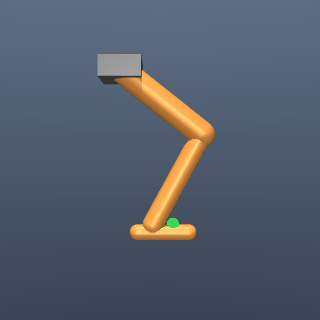

In [21]:
import imageio
from IPython.display import Image

class Camarografo:
    def __init__(self, modelo, trayectoria, cada: int = 10):
        self.camara = mujoco.Renderer(modelo, height=320, width=320)
        self.trayectoria, self.cada = trayectoria, cada
        self.fotos, self.pasos = [], 0

    def __call__(self, datos):
        datos.mocap_pos[0] = self.trayectoria.en(datos.time)[0]       # el marcador, al objetivo
        if self.pasos % self.cada == 0:
            mujoco.mj_forward(modelo, datos)                          # para que la foto vea el marcador movido
            self.camara.update_scene(datos, camera="lado")
            self.fotos.append(self.camara.render())
        self.pasos += 1

camarografo = Camarografo(modelo, circulo)
simular(modelo, EspacioTarea(circulo), 4.0, q_partida, al_paso=camarografo)
camarografo.camara.close()
os.makedirs("assets", exist_ok=True)
imageio.mimsave("assets/nb47_espacio_tarea.gif", camarografo.fotos, fps=50, loop=0)
print(len(camarografo.fotos), "fotos")
Image(filename="assets/nb47_espacio_tarea.gif")

El tobillo recorre el círculo, y el pie se mantiene **plano** en todo momento, mientras el muslo y la pierna se doblan y estiran lo que haga falta. ¿Y la bola verde? Casi no se ve: con un error de 8 mm y una bola de 2,5 cm de radio, el tobillo la lleva **tapada** casi todo el tiempo. Solo asoma al principio, cuando la pierna aún no ha llegado al círculo.

Compáralo con el GIF del NB46, donde colocábamos la pierna "a mano" con cinemática inversa: allí no había física (solo geometría) y el pie se inclinaba. Aquí hay **física de verdad**: masas, gravedad, inercias, motores con límite de par... y aun así el pie va donde debe y como debe.


## 10 · ¿Y para un bípedo?

Todo lo de hoy era con una pierna **colgada**: su base está fija, y los motores pueden hacer lo que quieran. En un bípedo que anda, la base (el torso) **no está fija**: está **subactuada** (sección 1). Los motores de las piernas solo pueden mover el torso **empujando el suelo**, y el suelo solo empuja (no tira), y con rozamiento limitado (NB48). Eso cambia las cosas:

- La **dinámica inversa** de un robot que anda tiene que repartir las fuerzas entre los pies que tocan el suelo, respetando que no resbalen ni se despeguen. Se resuelve como un problema de **optimización** en cada paso (con programación cuadrática, *QP*): es el **control de todo el cuerpo** (*whole-body control*), lo que usaba Atlas.
- El **espacio de la tarea** se generaliza a muchas tareas a la vez (centro de masas, orientación del torso, cada pie...), con prioridades.
- Y para decidir **dónde poner los pies**, hace falta **planificar** (NB51, NB52).

No vamos a programar un control de todo el cuerpo completo (es un curso en sí mismo), pero en el NB52 haremos andar a Zancudo con un controlador clásico sencillo, y entenderás perfectamente las piezas. Y lo más importante para la entrevista, la **comparación**:

| | Control con modelo | Aprendizaje por refuerzo |
|---|---|---|
| Necesita | un modelo **preciso** | un simulador (y mucho cálculo) |
| Garantías | muchas (estabilidad demostrable) | pocas |
| Robustez a modelo equivocado | regular (sección 8) | buena, si se entrena con aleatorización (NB55) |
| Contactos complicados, terreno irregular, caídas | difícil | lo aprende |
| Ajustar | ganancias con significado físico | recompensas e hiperparámetros |
| Lo que se usa hoy | en brazos industriales, en el control de bajo nivel, y combinado con RL | en casi todos los humanoides y cuadrúpedos nuevos |


## 11 · Resumen de la lección

1. **Controladores sin modelo** (PD, RL) frente a **con modelo** (usan M, c...).
2. **Dinámica inversa**: `mj_inverse` lee `qpos`, `qvel` y `qacc` (que pones tú) y escribe en `qfrc_inverse` las fuerzas necesarias. Ida y vuelta con la directa: salen los mismos pares. La raíz de un bípedo no tiene motor (**subactuación**).
3. MJCF: **siempre `<compiler angle="radian"/>`** (sin él, los ángulos del fichero se leen en grados). `<motor>` = par directo. Cuerpos **mocap**: se colocan a mano con `mocap_pos`.
4. **PD**: sin modelo; con la pierna quieta, la gravedad le deja un error permanente (la "caída").
5. **PD + gravedad** (`qfrc_bias`): error cero quieto y muy bueno despacio; empeora deprisa, porque no prevé la inercia.
6. **Par calculado**: `mj_inverse` con a = q̈_d + Kp·e + Kd·ė. Si el modelo es exacto, el error obedece ë + Kd·ė + Kp·e = 0 (**linealización por realimentación**): ω = √Kp, ζ = Kd/(2√Kp). Sigue bien a cualquier velocidad.
7. Con el **modelo equivocado** (+30 % de masa), el par calculado pierde casi toda su ventaja: el control con modelo es tan bueno como su modelo.
8. **Espacio de la tarea**: τ = Jᵀ·F + gravedad, con F un "PD del punto"; sin cinemática inversa; la orientación del pie con el jacobiano de rotación.
9. Python profesional (repaso del P2, P3 y P5, ahora en un diseño completo): **clases abstractas** (`ABC`, `@abstractmethod`: error al crear si falta un método), **`__call__`**, **protocolos** (`typing.Protocol`, tipado de pato documentado), **composición** frente a herencia (`Suma`), **patrón estrategia** y **fábrica**, ***callbacks*** (`al_paso`), acumular en listas y convertir al final, arrays de trabajo reutilizados. `mj_step1`/`mj_step2` para controlar con los datos del instante actual.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Dinámica inversa** | Calcular las fuerzas que producen una aceleración deseada. |
| **Compensación de la gravedad** | Sumar al control el par que hace la gravedad. |
| **Par calculado / linealización por realimentación** | Usar la dinámica inversa para que el error se comporte como un muelle lineal. |
| **Frecuencia natural ω / amortiguamiento ζ** | Lo rápido que vuelve el error a cero / si oscila (ζ < 1) o no (ζ ≥ 1). |
| **Amortiguamiento crítico** | ζ = 1: lo más rápido sin oscilar. |
| **Control en el espacio de la tarea** | Controlar un punto (el pie) con fuerzas virtuales, τ = Jᵀ·F. |
| **Control de todo el cuerpo** | Dinámica inversa con contactos, como optimización (QP), para robots con patas. |
| **Cuerpo mocap** | Cuerpo que no obedece a la física y se coloca a mano. |
| **Interfaz** | La "forma común" de usar una familia de objetos intercambiables. |
| **Clase abstracta** | Clase que no se puede crear y obliga a sus hijas a implementar ciertos métodos. |
| **Protocolo** | Interfaz que se cumple teniendo los métodos, sin heredar. |
| **Tipado de pato** | "Si anda como un pato...": importa lo que el objeto sabe hacer, no su clase. |
| **Composición** | Construir objetos que contienen a otros, en vez de heredar. |
| **Patrón estrategia / fábrica** | Pasar el comportamiento como un objeto intercambiable / crear objetos a partir de un nombre. |
| ***Callback*** | Función que se pasa a otra para que la llame en ciertos momentos. |


## 12 · Ejercicios

**E1.** Con el par calculado y el vaivén de 1 Hz, prueba ganancias para ω = 20 rad/s con ζ = 1 (Kp = 400, Kd = 40) para cadera y rodilla. ¿Cuánto baja el error? ¿Y los pares máximos que piden los motores? (Pista: `registro.ctrl`.)

**E2.** Arregla el par calculado con el modelo equivocado añadiendo un término **integral** (un PID, NB40): suma a la aceleración deseada Ki · (la suma acumulada de los errores × dt). Pruébalo con la postura fija y Ki = 200. ¿Desaparece el error?

**E3.** Repite la sección 8 con un modelo que cree que las piezas pesan un 30 % **menos**. ¿Es simétrico el efecto?

**E4.** Limita los motores a ±10 N·m (`modelo.actuator_ctrlrange[:] = [-10, 10]`, en una copia del modelo) y repite la carrera a 1 Hz con el par calculado. ¿Qué pasa cuando el controlador pide más par del que hay? (Esto se llama **saturación**.)

**E5.** Escribe un controlador como una **función normal** (no una clase): `def cero(modelo, datos): return np.zeros(modelo.nu)`, y pásaselo a `simular`. ¿Funciona? ¿Qué diría mypy, si `simular` está anotada con `Controlador`? ¿Cómo lo arreglarías con un protocolo?

**E6.** **Reto.** Haz que el tobillo dibuje un **ocho** (una lemniscata: x = c_x + r·sen(wt), z = c_z + r·sen(wt)·cos(wt)) con `EspacioTarea`, escribiendo una nueva clase de trayectoria. Mide el error RMS. ¿Qué tienes que cambiar en `EspacioTarea` o en `simular`? (Respuesta esperada: nada. Esa es la gracia del diseño.)


<details>
<summary>▶ Solución E1</summary>

```python
v = Vaiven(1.0)
q0, qd0, _ = v.en(0.0)
for kp, kd in [(100.0, 20.0), (400.0, 40.0)]:
    ganancias_p = np.array([kp, kp, 20.0])
    ganancias_d = np.array([kd, kd, 2.0])
    registro = simular(modelo, ParCalculado(v, modelo, kp=ganancias_p, kd=ganancias_d), 4.0, q0, qd0)
    print(kp, error_rms(registro, v), np.abs(registro.ctrl).max(axis=0))
```

El error baja de 0,0017 a **0,0011** rad (un 35 % menos). Y los pares máximos **casi no cambian** (unos 30 N·m en la cadera y 15 en la rodilla): con el par calculado, casi todo el par es la parte **prevista** (M·q̈_d + gravedad), y la realimentación solo corrige restos pequeños. Subir las ganancias "endurece" la corrección, pero sale casi gratis... en la simulación. En un robot real, ganancias altas amplifican el ruido de los sensores y los retrasos (NB41): el límite lo pone el hardware.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
class ParCalculadoPID(ParCalculado):
    def __init__(self, *args, ki: float = 200.0, **kwargs):
        super().__init__(*args, **kwargs)              # reutilizamos todo (NB25)
        self.ki = ki
        self.acumulado = np.zeros(3)

    def __call__(self, modelo, datos):
        q, qd, qdd = self.trayectoria.en(datos.time)
        self.acumulado += (q - datos.qpos) * modelo.opt.timestep      # la "suma" (integral) de los errores
        a = qdd + self.kp * (q - datos.qpos) + self.kd * (qd - datos.qvel) + self.ki * self.acumulado
        self.trabajo.qpos[:] = datos.qpos
        self.trabajo.qvel[:] = datos.qvel
        self.trabajo.qacc[:] = a
        mujoco.mj_inverse(self.modelo_interno, self.trabajo)
        return self.trabajo.qfrc_inverse.copy()

quieta = PosturaFija((0.5, -0.3, 0.0))
registro = simular(modelo, ParCalculadoPID(quieta, modelo_equivocado, ki=200.0), 10.0, quieta.q)
```

Sí, pero **despacio y oscilando**. Sin la integral, el error se queda en unos 0,06 rad para siempre. Con Ki = 200, el error va bajando, con altibajos, hasta unos **0,004 rad a los 10 segundos**: la integral va acumulando el error y empuja cada vez más hasta anularlo. Con Ki = 1000 es **peor**: oscila más y a los 10 s sigue en 0,035.

Es el gran compromiso de la parte integral de un PID: elimina los errores permanentes (como la caída por un peso mal estimado), pero añade **lentitud** y tendencia a **oscilar** (cuanto mayor Ki, más). Con el modelo exacto, la teoría de control (el criterio de Routh) dice que el sistema es estable mientras Ki < Kp · Kd (aquí, 2.000); cerca de ese límite, oscila cada vez más. Y una trampa clásica: si el motor se satura (E4), la integral sigue acumulando y luego tarda mucho en "descargarse" (*windup*); los controladores reales limitan el acumulado.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
modelo_ligero = mujoco.MjModel.from_xml_string(PIERNA)
modelo_ligero.body_mass[:] *= 0.7
modelo_ligero.body_inertia[:] *= 0.7
# y el mismo bucle de la sección 8 con ParCalculado(trayectoria, modelo_ligero)
```

Errores RMS de 0 a 1 Hz: **0,077, 0,083, 0,076, 0,085 y 0,127** rad, frente a 0,063, 0,064, 0,053, 0,059 y 0,085 con el +30 %. **No es simétrico**: subestimar las masas es peor que sobreestimarlas. Quieto, el controlador "ligero" no sostiene todo el peso y la pierna cae (como el PD); y a 1 Hz, sus aceleraciones se quedan cortas en todo el ciclo. En la práctica, si dudas, es preferible equivocarse por **arriba** en las masas (aunque lo correcto es medirlas, NB61).
</details>

<details>
<summary>▶ Solución E4</summary>

```python
limitado = mujoco.MjModel.from_xml_string(PIERNA)
limitado.actuator_ctrlrange[:] = [-10, 10]
v = Vaiven(1.0)
q0, qd0, _ = v.en(0.0)
registro = simular(limitado, ParCalculado(v, limitado), 4.0, q0, qd0)
print(error_rms(registro, v), np.abs(registro.ctrl).max(axis=0))
```

El error se dispara a **0,44 rad** (250 veces más que sin límite). La pierna necesita unos 30 N·m en la cadera para ese movimiento y solo hay 10: se queda atrás, el error crece, el controlador pide cada vez **más** (¡hasta 716 N·m en la rodilla, según `ctrl`!) y el motor solo da 10. `ctrl` guarda lo que **pedimos**; MuJoCo lo recorta al aplicarlo (por `ctrlrange` y `ctrllimited`).

Es la **saturación**, y es el problema número uno del control en robots reales: los motores tienen límites de par, de velocidad y de corriente. Un buen controlador **sabe** de sus límites y planifica movimientos que se puedan hacer. Por eso los controladores predictivos (MPC) incluyen los límites en su optimización, y por eso en RL se incluyen en el simulador (NB54).
</details>

<details>
<summary>▶ Solución E5</summary>

```python
def cero(modelo, datos):
    return np.zeros(modelo.nu)

registro = simular(modelo, cero, 1.0, q_inicial=[0.0, -0.8, 0.0])     # ¡funciona!
```

**Funciona**, porque `simular` solo hace `controlador(modelo, datos)`, y una función normal se puede llamar así (tipado de pato). Pero **mypy protestaría**: `simular` dice que quiere un `Controlador`, y una función no hereda de `Controlador`. La solución profesional es anotar `simular` con un **protocolo** de "cosa llamable", que la función cumple:

```python
class ControladorLlamable(Protocol):
    def __call__(self, modelo: mujoco.MjModel, datos: mujoco.MjData) -> np.ndarray: ...
```

Las funciones normales y los objetos con `__call__` (como nuestros controladores) cumplen ese protocolo; es lo mismo que hacía la `Politica` del P5. (Para algo tan sencillo, también vale `Callable[[mujoco.MjModel, mujoco.MjData], np.ndarray]`, del P5.) Así se tiene lo mejor de los dos mundos: la clase abstracta para **nuestros** controladores, y el protocolo para **aceptar** cualquier cosa que sepa comportarse como uno.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
@dataclass(frozen=True)
class Ocho:
    centro: tuple[float, float, float] = (0.1, 0.0, 0.6)
    radio: float = 0.12
    frecuencia: float = 0.5

    def en(self, t):
        w = 2 * np.pi * self.frecuencia
        c = np.array(self.centro)
        s, co = np.sin(w * t), np.cos(w * t)
        x = c + self.radio * np.array([s, 0.0, s * co])
        v = self.radio * w * np.array([co, 0.0, co**2 - s**2])    # derivada de sen·cos = cos² − sen²
        return x, v, np.zeros(3)

ocho = Ocho()
registro = simular(modelo, EspacioTarea(ocho), 4.0, q_partida)
# error como en la sección 9, a partir del segundo 1
```

Error RMS de unos **11 mm** (máximo, 18 mm): un poco más que el círculo, porque el ocho tiene curvas más cerradas. Y lo importante: **no hemos cambiado ni una línea** de `EspacioTarea` ni de `simular`. Una clase nueva que cumple el protocolo `Trayectoria` (tiene `en`) y ya está. Eso es lo que compra un buen diseño de interfaces: **añadir sin tocar**. (En ingeniería de software, a esto se le llama el principio **abierto/cerrado**: abierto a extensiones, cerrado a modificaciones.)
</details>


## 13 · 🛠 Práctica en MuJoCo: servos que saben física (Zancudo entero)

Todo lo de hoy lo has hecho con una pierna suelta y **motores de par**. Pero muchos robots reales (y nuestro Zancudo v2, el del NB50) no tienen motores de par: tienen **servos de posición**, a los que solo les puedes decir "ponte en este ángulo". ¿Se puede aprovechar la dinámica inversa con ellos?

Sí, y es lo que hacen muchísimos robots comerciales: se llama **prealimentación** (*feedforward*). La idea, en una frase: si sabes qué par va a hacer falta, **le cambias la consigna al servo** para que, al intentar corregir el "error" que tú le inventas, empuje justo con ese par. Hoy lo harás con Zancudo **entero** (las dos piernas a la vez, colgado de su grúa) y vas a descubrir algo que la sección 8 dejó en el aire: la prealimentación con servos es **mucho más robusta** a un modelo equivocado que el par calculado puro.

En el NB46 viste que los servos de Zancudo llegaban tarde (4,4 cm de error en el pie) y lo arreglaste con un truco de tiempo. Hoy lo arreglarás con física.


### Paso 1 · ¿Qué hace exactamente un servo de Zancudo v2?

Sus actuadores son de tipo `general` (NB50), con tres números en el modelo: la ganancia (`gainprm`) y el sesgo (`biasprm`). La fuerza que hacen es:

```
   fuerza = gainprm[0] · ctrl  +  biasprm[0]  +  biasprm[1] · q  +  biasprm[2] · q̇
          =      300  · ctrl  +       0      −       300  · q  −       20  · q̇
          =  300 · (ctrl − q)  −  20 · q̇
```

Un muelle de 300 N·m/rad hacia la consigna, más un amortiguador de 20 N·m·s/rad. Comprobémoslo con un estado cualquiera:


In [22]:
import taller

zv2 = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
zv2.eq_active0[0] = 1                    # la grúa, encendida por defecto en todos los MjData de este modelo
print("gainprm:", zv2.actuator_gainprm[0, :3], "  biasprm:", zv2.actuator_biasprm[0, :3])

d = mujoco.MjData(zv2)
mujoco.mj_resetDataKeyframe(zv2, d, 1)   # "colgado"
d.qvel[3:] = [1.0, -2.0, 0.5, 0.0, 0.3, -1.0]
d.ctrl[:] = d.qpos[3:] + 0.1
mujoco.mj_forward(zv2, d)
a_mano = 300 * (d.ctrl - d.qpos[3:]) - 20 * d.qvel[3:]
print("a mano:", a_mano)
print("MuJoCo:", d.actuator_force)
print("¿grúa encendida?", d.eq_active)

gainprm: [300.   0.   0.]   biasprm: [   0. -300.  -20.]
a mano: [10. 70. 20. 30. 24. 50.]
MuJoCo: [10. 70. 20. 30. 24. 50.]
¿grúa encendida? [ True]


Coinciden. (Fíjate en `eq_active0`: es el valor **inicial** de `eq_active` que copia cada `MjData` nuevo. Cambiándolo en el modelo, todos los datos que creemos, incluidos los de la función `simular` de la sección 3, nacen con la grúa puesta.)

Y fíjate en el **−20 · q̇**: el amortiguador frena **cualquier** velocidad, también la que tú le pides. Si quieres que la cadera se mueva a 1 rad/s, el servo te está frenando con 20 N·m. Ese es el origen principal del retraso que viste en el NB46.

### Paso 2 · El truco de la consigna desplazada

Queremos que el servo haga un par total τ (el que dice `mj_inverse`). Despejando de la fórmula, cuando la articulación va justo por la trayectoria (q = q_d, q̇ = q̇_d):

```
   τ = 300 · (ctrl − q_d) − 20 · q̇_d      →      ctrl = q_d + (τ + 20 · q̇_d) / 300
```

Es decir: le pedimos al servo un ángulo **un poco desplazado** respecto al que queremos, justo lo necesario para que su muelle empuje con el par que hace falta (y compense su propio amortiguador). Y si la pierna se desvía de la trayectoria, el muelle de 300 sigue ahí para corregir: **realimentación** de propina.

### Paso 3 · La trayectoria: marchar en el aire

Las dos piernas se balancean a la vez, en **contrafase** (cuando una va hacia delante, la otra va hacia atrás), como al marchar. Es una dataclass congelada con el método `en(t)`, así que **cumple el protocolo `Trayectoria`** de la sección 3 sin heredar de nada:


In [23]:
@dataclass(frozen=True)
class MarchaAire:
    frecuencia: float
    centro: tuple[float, float, float] = (0.5, -1.0, 0.5)     # la postura "colgado"
    amplitud: tuple[float, float, float] = (0.4, 0.4, 0.0)    # cadera y rodilla; el tobillo, quieto

    def en(self, t: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        w = 2 * np.pi * self.frecuencia
        c, a = np.array(self.centro), np.array(self.amplitud)
        partes = []
        for desfase in (0.0, np.pi):                            # derecha, izquierda (media vuelta después)
            s, co = np.sin(w * t + desfase), np.cos(w * t + desfase)
            partes.append((c + a * s, a * w * co, -a * w**2 * s))
        return tuple(np.concatenate([partes[0][i], partes[1][i]]) for i in range(3))

q, qd, qdd = MarchaAire(1.0).en(0.1)
print("ángulos deseados a t = 0,1 s:", q)

ángulos deseados a t = 0,1 s: [ 0.7351 -0.7649  0.5     0.2649 -1.2351  0.5   ]


Seis ángulos: las tres articulaciones de la pierna derecha y las tres de la izquierda.

### Paso 4 · Dos estrategias, de la familia `Controlador`

Las dos heredan de la clase abstracta de la sección 3 y devuelven el vector `ctrl`. La diferencia es que aquí `ctrl` son **consignas de ángulo**, no pares:

- **`ServoSolo`**: le da al servo el ángulo deseado, sin más. Lo que haría cualquiera.
- **`ServoPrealimentado`**: calcula con `mj_inverse` (con su **propio** modelo interno y sus propios datos, como `ParCalculado`) el par que hace falta para la aceleración deseada, y desplaza la consigna. La raíz está sujeta por la grúa, así que le pedimos aceleración cero.


In [24]:
KP_SERVO, KD_SERVO = 300.0, 20.0

class ServoSolo(Controlador):
    def __init__(self, trayectoria: Trayectoria):
        self.trayectoria = trayectoria
    def __call__(self, modelo, datos):
        return self.trayectoria.en(datos.time)[0]
    def __repr__(self):
        return "ServoSolo()"

class ServoPrealimentado(Controlador):
    def __init__(self, trayectoria: Trayectoria, modelo_interno: mujoco.MjModel):
        self.trayectoria = trayectoria
        self.modelo_interno = modelo_interno
        self.trabajo = mujoco.MjData(modelo_interno)
    def __call__(self, modelo, datos):
        q, qd, qdd = self.trayectoria.en(datos.time)
        self.trabajo.qpos[:] = datos.qpos
        self.trabajo.qvel[:] = datos.qvel
        self.trabajo.qacc[:3] = 0.0                     # la raíz, quieta (la sujeta la grúa)
        self.trabajo.qacc[3:] = qdd                     # las piernas, la aceleración de la trayectoria
        mujoco.mj_inverse(self.modelo_interno, self.trabajo)
        tau = self.trabajo.qfrc_inverse[3:]             # el par que necesita cada articulación
        return q + (tau + KD_SERVO * qd) / KP_SERVO     # la consigna desplazada
    def __repr__(self):
        return "ServoPrealimentado()"

Para medir, reutilizamos la función `simular` de la sección 3 (¡ahí está la gracia de haberla escrito genérica!), con un *callback* `al_paso` que apunta los pares reales de los motores. El error lo medimos en caderas y rodillas, a partir del primer segundo:


In [25]:
def marchar(fabrica_controlador, frecuencia: float, segundos: float = 4.0) -> tuple[float, float]:
    trayectoria = MarchaAire(frecuencia)
    q0, qd0, _ = trayectoria.en(0.0)
    q_inicial = np.concatenate([np.zeros(3), q0])                 # raíz en su sitio + piernas sobre la trayectoria
    qd_inicial = np.concatenate([np.zeros(3), qd0])
    pares = []
    registro = simular(zv2, fabrica_controlador(trayectoria), segundos, q_inicial, qd_inicial,
                       al_paso=lambda datos: pares.append(datos.actuator_force.copy()))
    despues = registro.tiempo > 1.0
    deseadas = np.array([trayectoria.en(t)[0] for t in registro.tiempo[despues]])
    errores = registro.qpos[despues][:, 3:] - deseadas
    rms = float(np.sqrt(np.mean(errores[:, [0, 1, 3, 4]] ** 2)))   # caderas y rodillas
    return rms, float(np.abs(np.array(pares)[despues]).max())

estrategias = {
    "servo solo": ServoSolo,
    "servo prealimentado": lambda tr: ServoPrealimentado(tr, zv2),
}
print(f"{'':<22}" + "".join(f"{f:>16} Hz" for f in [0.5, 1.0, 2.0]))
for nombre, fabrica in estrategias.items():
    filas = [marchar(fabrica, f) for f in [0.5, 1.0, 2.0]]
    print(f"{nombre:<22}" + "".join(f"  {e:.4f} rad {p:5.1f} N·m" for e, p in filas))

                                   0.5 Hz             1.0 Hz             2.0 Hz


servo solo              0.0613 rad   8.5 N·m  0.1282 rad  17.2 N·m  0.3139 rad 106.8 N·m


servo prealimentado     0.0002 rad   8.8 N·m  0.0009 rad  18.5 N·m  0.0037 rad 107.0 N·m


Cada casilla es "error RMS, par máximo". Léelo despacio:

- **Servo solo**: 0,061 rad a 0,5 Hz, 0,128 a 1 Hz y **0,314 rad (18°)** a 2 Hz. Va siempre por detrás, y cuanto más rápido, peor (sobre todo por el amortiguador que frena el movimiento pedido, y por la inercia a 2 Hz).
- **Servo prealimentado**: **0,0002**, **0,0009** y **0,0037 rad**. Entre **85 y 300 veces menos error**, con los mismos servos y los mismos motores. Lo único que ha cambiado es **qué ángulo** les pedimos.
- **El par máximo** es prácticamente el mismo en las dos estrategias (≈ 107 N·m a 2 Hz, dentro de los ±150 que admite Zancudo). La prealimentación no "empuja más fuerte": empuja **a tiempo**.

### Paso 5 · La prueba de la sección 8: un modelo equivocado

Ahora el controlador cree que las piezas pesan un 30 % más de lo que pesan. En la sección 8, eso hundía al par calculado. ¿Y aquí?


In [26]:
zv2_equivocado = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
zv2_equivocado.eq_active0[0] = 1
zv2_equivocado.body_mass[:] *= 1.3
zv2_equivocado.body_inertia[:] *= 1.3

for f in [0.5, 1.0, 2.0]:
    e_bien, _ = marchar(lambda tr: ServoPrealimentado(tr, zv2), f)
    e_mal, _ = marchar(lambda tr: ServoPrealimentado(tr, zv2_equivocado), f)
    e_solo, _ = marchar(ServoSolo, f)
    print(f"{f} Hz:  modelo bien {e_bien:.4f}   modelo +30 % {e_mal:.4f}   servo solo {e_solo:.4f} rad")

0.5 Hz:  modelo bien 0.0002   modelo +30 % 0.0050   servo solo 0.0613 rad


1.0 Hz:  modelo bien 0.0009   modelo +30 % 0.0097   servo solo 0.1282 rad


2.0 Hz:  modelo bien 0.0037   modelo +30 % 0.0529   servo solo 0.3139 rad


Con el modelo equivocado, el error sube (de 0,0002 a 0,005 a 0,5 Hz; a 0,053 a 2 Hz), pero sigue siendo **entre 6 y 13 veces mejor** que el servo solo. Para comparar: un par calculado puro con las ganancias de la sección 6 sobre este mismo Zancudo (es el reto R1) pasa de 0,0004 a **0,076 rad** con el mismo +30 %: **15 veces peor** que la prealimentación equivocada.

¿Por qué esta robustez? Porque aquí hay **dos** cosas trabajando juntas:

1. La **prealimentación** pone el grueso del par, a tiempo, gracias al modelo. Si el modelo se equivoca un 30 %, se equivoca en un 30 % del par... pero acierta en el 70 % restante.
2. La **realimentación** rígida del servo (300 N·m/rad) corrige lo que el modelo no ha previsto.

El par calculado puro, en cambio, confía en el modelo **también** para convertir sus correcciones en pares (las multiplica por la M equivocada). Esta combinación, "**prealimentación con el modelo + realimentación rígida**", es la receta estándar de los brazos industriales y de muchos robots con patas. Y es una respuesta muy buena para la pregunta de entrevista "¿cómo usarías el modelo si no te fías del todo de él?".

### Paso 6 · Verlo

Zancudo marchando en el aire a 1 Hz con los servos prealimentados:


In [27]:
marcha = MarchaAire(1.0)
d = mujoco.MjData(zv2)
q0, qd0, _ = marcha.en(0.0)
d.qpos[3:], d.qvel[3:] = q0, qd0
mujoco.mj_forward(zv2, d)
prealimentado = ServoPrealimentado(marcha, zv2)

def control_marcha(modelo, datos):
    datos.ctrl[:] = prealimentado(modelo, datos)

_ = taller.video(zv2, d, segundos=3.0, control=control_marcha, nombre="nb47_marcha_prealimentada", distancia=2.4)

(Aquí `taller.video` llama al control **antes** de `mj_step`, sin `mj_step1`: el controlador ve los datos calculados en el paso anterior. Para un controlador que solo lee `qpos` y `qvel` y llama a `mj_inverse` con sus propios datos, da igual: no usa nada "desfasado" de `datos`.)


### Tus retos

**R1.** Convierte los servos de una **copia** de Zancudo v2 en **motores de par** cambiando sus parámetros (`gainprm[:, 0] = 1`, `biasprm[:, :3] = 0`, `ctrlrange = ±150`) y escribe un `ParCalculadoZancudo` (como el de la sección 6, pero con la raíz a aceleración cero y devolviendo solo `qfrc_inverse[3:]`). Mide el error a 0,5, 1 y 2 Hz con el modelo bien y con el +30 %.

**R2.** ¿Qué parte del retraso del servo solo viene del **amortiguador**? Prueba una tercera estrategia que solo compense el amortiguador: `ctrl = q_d + 20 · q̇_d / 300`, sin `mj_inverse`.

**R3.** Sube a **3 Hz**. ¿Siguen cabiendo los pares en los ±150 N·m? ¿Qué pasa con el error si no caben?


<details>
<summary>▶ Solución R1</summary>

```python
zv2_par = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
zv2_par.eq_active0[0] = 1
zv2_par.actuator_gainprm[:, 0] = 1.0           # fuerza = 1 · ctrl
zv2_par.actuator_biasprm[:, :3] = 0.0          # sin muelle ni amortiguador
zv2_par.actuator_ctrlrange[:] = [-150, 150]    # ctrl ahora son N·m

class ParCalculadoZancudo(Controlador):
    def __init__(self, trayectoria, modelo_interno, kp=100.0, kd=20.0):
        self.trayectoria, self.modelo_interno = trayectoria, modelo_interno
        self.trabajo = mujoco.MjData(modelo_interno)
        self.kp, self.kd = kp, kd
    def __call__(self, modelo, datos):
        q, qd, qdd = self.trayectoria.en(datos.time)
        self.trabajo.qpos[:], self.trabajo.qvel[:] = datos.qpos, datos.qvel
        self.trabajo.qacc[:3] = 0.0
        self.trabajo.qacc[3:] = qdd + self.kp * (q - datos.qpos[3:]) + self.kd * (qd - datos.qvel[3:])
        mujoco.mj_inverse(self.modelo_interno, self.trabajo)
        return self.trabajo.qfrc_inverse[3:].copy()
```

Para medirlo, `marchar` usa `zv2`: hazle una copia que reciba el modelo como argumento, o cambia temporalmente `zv2` por `zv2_par`. Resultados (ejecutado): con el modelo bien, **0,0004 / 0,0014 / 0,0034 rad**, casi igual que la prealimentación; con el +30 % (modelo interno = `zv2_equivocado`), **0,076 / 0,093 / 0,164 rad**: peor que la prealimentación equivocada en todas las frecuencias, y a 0,5 Hz incluso **peor que el servo solo** (0,076 frente a 0,061). Es la sección 8 otra vez, en el robot entero. Subir kp a 400 (y kd a 40) apenas cambia el caso bueno (0,0003 / 0,0009 / 0,0030).
</details>

<details>
<summary>▶ Solución R2</summary>

```python
class ServoConAmortiguador(Controlador):
    def __init__(self, trayectoria):
        self.trayectoria = trayectoria
    def __call__(self, modelo, datos):
        q, qd, _ = self.trayectoria.en(datos.time)
        return q + KD_SERVO * qd / KP_SERVO

for f in [0.5, 1.0, 2.0]:
    print(f, marchar(ServoConAmortiguador, f))
```

Resultado (ejecutado): **0,0156 / 0,0342 / 0,187 rad** a 0,5 / 1 / 2 Hz. Comparado con el servo solo (0,061 / 0,128 / 0,314), a frecuencias bajas desaparecen **tres cuartas partes** del error solo con esto: ahí casi todo el retraso es el amortiguador frenando la velocidad pedida. A 2 Hz ya no basta (sigue en 0,19 rad, 50 veces más que la prealimentación completa): aparecen la inercia (que crece con la frecuencia al cuadrado, sección 3) y la gravedad, y para eso hace falta el modelo completo.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
for nombre, fabrica in estrategias.items():
    print(nombre, marchar(fabrica, 3.0))
```

Resultado (ejecutado): el par máximo llega a **150 N·m** en las dos estrategias: los motores **saturan** (`forcerange` del actuador). A 3 Hz las aceleraciones son (3/2)² = 2,25 veces las de 2 Hz, y el par necesario ya no cabe. El servo solo se va a 0,381 rad, y el prealimentado, de 0,0037 a **0,084 rad**: 23 veces más que a 2 Hz. Cuando el motor satura, la prealimentación ya no puede dar el par que pide el modelo, y el error crece de golpe: es el ejercicio E4, ahora con Zancudo entero. Ninguna estrategia de control puede sacar más par del que tiene el motor; la solución es pedir trayectorias más suaves (NB51).
</details>


### Qué has aprendido de MuJoCo hoy

- Los actuadores **`general`** con sesgo afín son servos de posición: fuerza = gainprm·ctrl + biasprm·(1, q, q̇). Puedes comprobarlo con `actuator_force` y **convertirlos** en motores de par cambiando esos números.
- **`eq_active0`** decide si una restricción (la grúa) nace encendida en cada `MjData`.
- **`mj_inverse`** sirve también con servos de posición: desplazando la consigna, ctrl = q_d + (τ + kd·q̇_d)/kp, el servo entrega el par de la dinámica inversa. Con Zancudo entero, el error baja entre 85 y 300 veces.
- **Prealimentación + realimentación rígida** es mucho más robusta a un modelo equivocado que el par calculado puro.

En la práctica del NB48 bajarás a Zancudo de la grúa y estudiarás lo único que lo sostiene cuando está en el suelo: los **contactos**. Lo pondrás de pie sobre un suelo blando, ajustando `solref` y `solimp`, y medirás cuánto se hunde.


## 14 · Posdata

Si algo no ha quedado claro (también en la práctica en MuJoCo), dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB48** abrimos la caja negra de los **contactos**: cómo detecta MuJoCo qué toca qué, cómo calcula las fuerzas de contacto (el modelo "blando" de `solref` y `solimp`), el rozamiento y su cono, los distintos solucionadores, y cómo medir las fuerzas de reacción del suelo y el **centro de presiones** (el ZMP del NB39, ¡medido de verdad!). En Python, repasaremos en acción lo del P3 y el P4: generadores e iteradores, `NamedTuple` e `itertools`.
